# Tuning a Pretrained Model (Transfer Learning with Keras)

Training an image classifier "from scratch" normally needs thousands of
labeled images. **Transfer learning** sidesteps that: we start from a model
that has already learned to recognize general image features (edges,
textures, shapes) from 1.4 million ImageNet photos, and only teach it the
last, small step - telling *our* classes apart.

**Pipeline, step by step:**
1. Load a folder of labeled images (one sub-folder per class).
2. Load a pretrained model (Xception) *without* its final classification
   layer, and freeze its weights so training doesn't change them.
3. Add a new, untrained final layer for our own classes and train
   *only that layer* ("transfer learning").
4. Unfreeze the whole model and keep training a little more, with a very
   small learning rate, so it adapts to our images ("fine-tuning").
5. Evaluate with a confusion matrix and look at example predictions.

**A note on this environment:** step 1 needs a folder of real images, and
step 2 needs to download ~90MB of pretrained weights from the internet.
Neither is available in a sandboxed/offline environment, so this notebook
automatically falls back to (a) a small synthetic image dataset and
(b) a randomly-initialized model, so every cell still runs to completion.
Messages printed along the way tell you which mode you're in. On a machine
with internet access and the real dataset in place, the same code uses the
real data and real pretrained weights - no changes needed.

## Setup

In [6]:
# If a library below is missing, uncomment the matching line and run this cell.
#%pip install tensorflow
#%pip install scikit-learn
#%pip install pillow
#%pip install pandas
#%pip install matplotlib

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras.applications import xception

## Dataset

We expect a folder with one sub-folder per class, each full of images,
e.g.:

```
data/raw/tree_species/
    oak/
        img001.jpg
        img002.jpg
        ...
    pine/
        img001.jpg
        ...
```

If that folder doesn't exist, we generate a small synthetic dataset with
the same structure (simple shapes instead of real photos) so the rest of
the notebook still has something to train on.

In [2]:
DATA_DIR = Path("../data/raw/tree_species/")
CLASS_NAMES = ["oak", "pine"]  # sub-folder names = class names
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 10
SEED = 0
VALIDATION_SPLIT = 0.5

# Keep training fast in this sandbox. If you have real data + a GPU,
# increase these for a much better model.
EPOCHS_TRANSFER = 3
EPOCHS_FINE_TUNE = 3

In [3]:
def make_synthetic_dataset(root, class_names, image_size, images_per_class=40, seed=0):
    # Create a tiny fallback image dataset: circles for one class, triangles
    # for the other, on randomly colored backgrounds. This only exists so
    # that image_dataset_from_directory() below has real files to read when
    # no real dataset is available.
    from PIL import Image, ImageDraw

    rng = np.random.default_rng(seed)
    root.mkdir(parents=True, exist_ok=True)
    for class_idx, class_name in enumerate(class_names):
        class_dir = root / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        for i in range(images_per_class):
            bg = tuple(rng.integers(150, 256, size=3).tolist())
            fg = tuple(rng.integers(0, 120, size=3).tolist())
            img = Image.new("RGB", image_size, bg)
            draw = ImageDraw.Draw(img)
            w, h = image_size
            if class_idx == 0:
                # class 0: circle-ish shape
                draw.ellipse((w * 0.2, h * 0.2, w * 0.8, h * 0.8), fill=fg)
            else:
                # class 1: triangle-ish shape
                draw.polygon([(w * 0.5, h * 0.15), (w * 0.85, h * 0.85), (w * 0.15, h * 0.85)], fill=fg)
            img.save(class_dir / f"{class_name}_{i:03d}.jpg")


if DATA_DIR.exists() and any(DATA_DIR.iterdir()):
    print(f"Using real dataset found at {DATA_DIR}.")
    using_real_dataset = True
else:
    print(f"No dataset found at {DATA_DIR}. Generating a small synthetic dataset instead.")
    DATA_DIR = Path("synthetic_tree_species")
    make_synthetic_dataset(DATA_DIR, CLASS_NAMES, IMAGE_SIZE, seed=SEED)
    using_real_dataset = False

No dataset found at ../data/raw/tree_species. Generating a small synthetic dataset instead.


In [4]:
from pathlib import Path

print("Current folder:", Path.cwd())

for p in Path(".").rglob("*"):
    if p.is_dir() and p.name.lower() in ["oak", "pine", "tree_species"]:
        print(p)


Current folder: /Users/Silicon14/Bigdata/Notebooks-20230118/Bigdatabase
synthetic_tree_species/oak
synthetic_tree_species/pine


In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VALIDATION_SPLIT,
    subset="training",
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
)

class_names = [name.replace("_", " ") for name in train_ds.class_names]
train_ds.class_names = class_names
val_ds.class_names = class_names

# Cache the (small) datasets in memory so we don't re-read images from
# disk on every epoch.
train_ds = train_ds.cache()
val_ds = val_ds.cache()

Found 80 files belonging to 2 classes.
Using 40 files for training.
Found 80 files belonging to 2 classes.
Using 40 files for validation.


2026-09-04 18:55:27.465176: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-09-04 18:55:27.465213: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-04 18:55:27.465232: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-09-04 18:55:27.465647: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-04 18:55:27.466003: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-09-04 18:55:32.683828: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


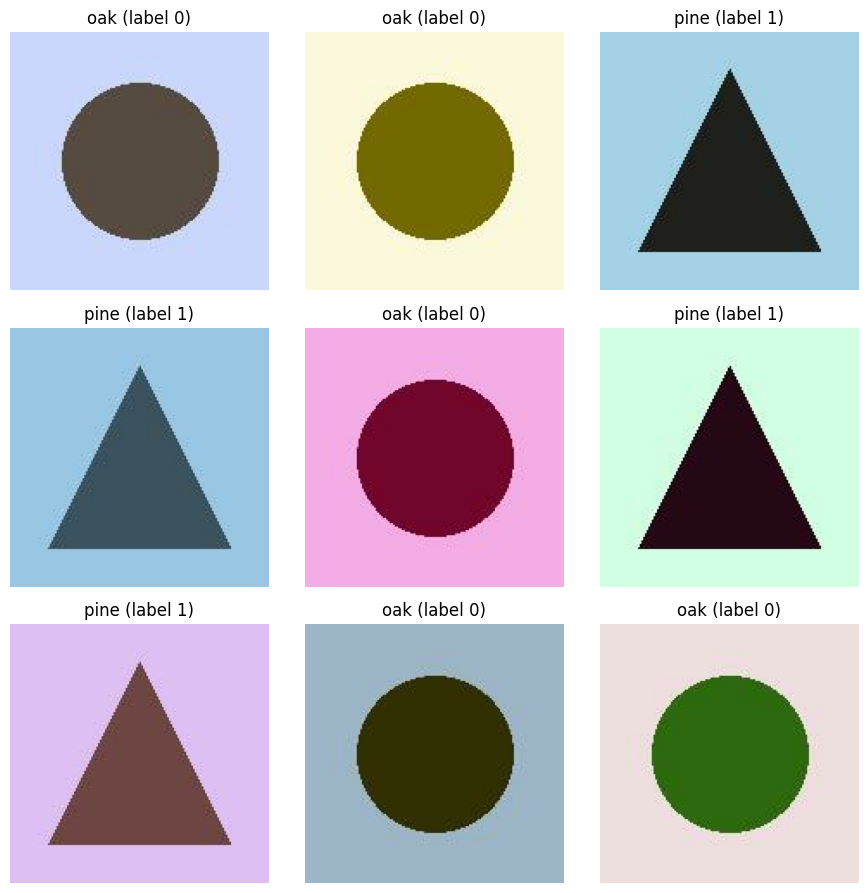

In [5]:
def show_dataset(ds, class_names=None, max_images=9):
    # Display a grid of images with their labels, for a quick sanity check.
    if class_names is None:
        class_names = ds.class_names

    images_shown = list(ds.unbatch().take(max_images).as_numpy_iterator())
    num_cols = 3
    num_rows = len(images_shown) // num_cols + 1

    plt.figure(figsize=(num_cols * 3, num_rows * 3))
    for i, (image, label) in enumerate(images_shown):
        ax = plt.subplot(num_rows, num_cols, i + 1)
        ax.imshow(image.astype("uint8"))
        plt.title(f"{class_names[label]} (label {label})")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_dataset(train_ds, class_names=class_names)

2026-09-04 18:55:53.905465: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


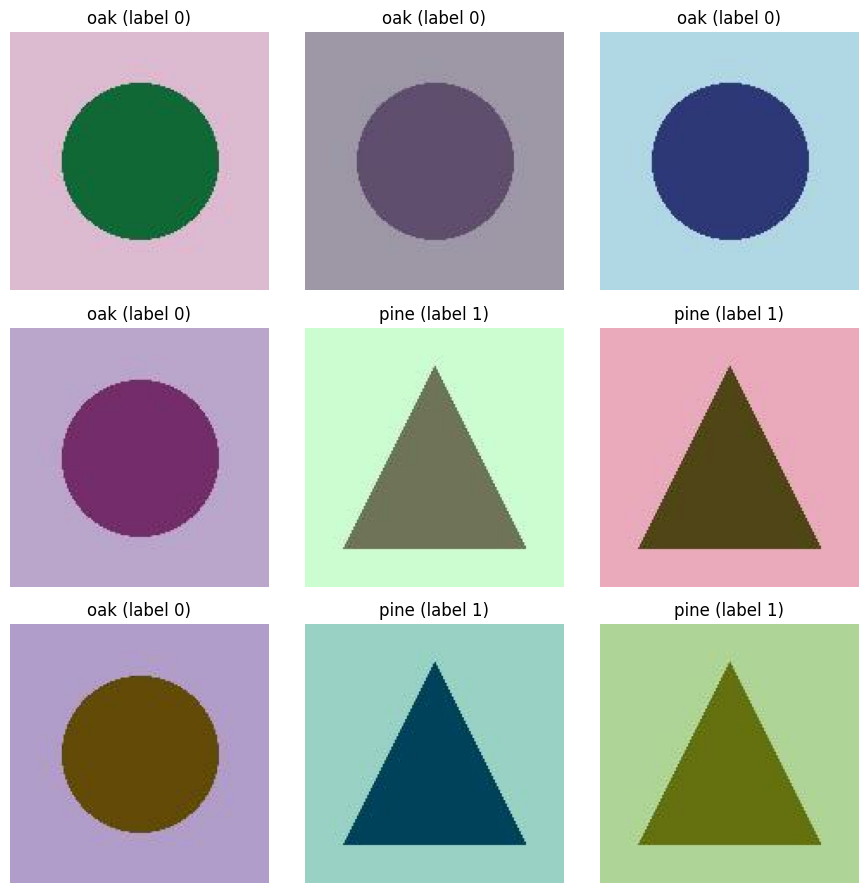

In [6]:
show_dataset(val_ds, class_names=class_names)

## Transfer Learning

Pretrained models expect their input images preprocessed in a specific
way (Xception scales pixel values to the range [-1, 1]). We apply the
same preprocessing here so the pretrained weights work correctly on our
images.

In [7]:
preprocessed_train_ds = train_ds.map(lambda x, y: (xception.preprocess_input(x), y))
preprocessed_val_ds = val_ds.map(lambda x, y: (xception.preprocess_input(x), y))

# sanity check: preprocessing should map pixel values into [-1, 1]
image_batch, labels_batch = next(iter(preprocessed_train_ds))
float(image_batch[0].numpy().min()), float(image_batch[0].numpy().max())

(-0.5058823823928833, 1.0)

In [8]:
input_shape = IMAGE_SIZE + (3,)

try:
    # weights="imagenet" downloads ~90MB of pretrained weights from the
    # internet the first time it's used. This is the whole point of
    # transfer learning: these weights already "know" how to see.
    base_model = xception.Xception(
        weights="imagenet",
        input_shape=input_shape,
        include_top=False,  # drop the original 1000-class classification layer
    )
    print("Loaded Xception with pretrained ImageNet weights.")
    using_pretrained_weights = True
except Exception as err:
    # No internet access (or the download failed) -> fall back to random
    # initial weights so the notebook still runs. The mechanics below are
    # identical either way; only the starting point of the weights differs.
    print(f"Could not download pretrained weights ({err}). Using random initial weights instead.")
    base_model = xception.Xception(
        weights=None,
        input_shape=input_shape,
        include_top=False,
    )
    using_pretrained_weights = False

base_model.summary()

Loaded Xception with pretrained ImageNet weights.
Model: "xception"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 74, 74, 32)           864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 74, 74, 32)           128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 74, 7

In [9]:
# Freeze the pretrained model: don't update its weights yet, we only
# want to train the new layer we're about to add on top of it.
base_model.trainable = False

In [10]:
inputs = keras.Input(shape=input_shape)
# Run the base model in inference mode (training=False) even while our
# own layers are being trained - this matters later for its BatchNorm
# layers, see the fine-tuning section below.
x = base_model(inputs, training=False)
# Collapse the base model's spatial feature maps down to one vector per image
x = keras.layers.GlobalAveragePooling2D()(x)
# The only layer we actually train in this first phase
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[keras.metrics.BinaryAccuracy()],
)
# Notice how few parameters are "Trainable" - almost the whole network
# is frozen; we're only training the one Dense layer we just added.
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 xception (Functional)       (None, 5, 5, 2048)        20861480  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 1)                 2049      
                                                                 
Total params: 20863529 (79.59 MB)
Trainable params: 2049 (8.00 KB)
Non-trainable params: 20861480 (79.58 MB)
_________________________________________________________________


In [12]:
def history_to_df(history, phase_name=np.nan):
    # Turn a Keras History object into a DataFrame we can plot/concatenate.
    df_history = pd.DataFrame(history.history)
    df_history.insert(0, "epoch", history.epoch)
    df_history.insert(1, "phase", phase_name)
    return df_history


def record_history(df_history, new_history, phase_name=np.nan):
    # Append a new training run's history, continuing the epoch numbering
    # from wherever the previous run left off (used for the fine-tuning
    # phase below).
    df_new_history = history_to_df(new_history, phase_name)
    df_new_history["epoch"] += df_history.shape[0]
    return pd.concat([df_history, df_new_history]).reset_index(drop=True)

In [13]:
history = model.fit(preprocessed_train_ds, epochs=EPOCHS_TRANSFER, validation_data=preprocessed_val_ds)
df_history = history_to_df(history, "transfer")
df_history

Epoch 1/3


2026-09-04 18:56:33.938041: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-09-04 18:56:34.002064: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


4/4 [==============================] - 3s 371ms/step - loss: 0.6366 - binary_accuracy: 0.7000 - val_loss: 0.4959 - val_binary_accuracy: 0.8500
Epoch 2/3
4/4 [==============================] - 0s 86ms/step - loss: 0.4130 - binary_accuracy: 0.9500 - val_loss: 0.3419 - val_binary_accuracy: 0.9750
Epoch 3/3
4/4 [==============================] - 0s 87ms/step - loss: 0.2822 - binary_accuracy: 1.0000 - val_loss: 0.2458 - val_binary_accuracy: 1.0000


,epoch,phase,loss,binary_accuracy,val_loss,val_binary_accuracy
0,0,transfer,0.636576,0.70,0.495860,0.850
1,1,transfer,0.413004,0.95,0.341865,0.975
2,2,transfer,0.282244,1.00,0.245806,1.000


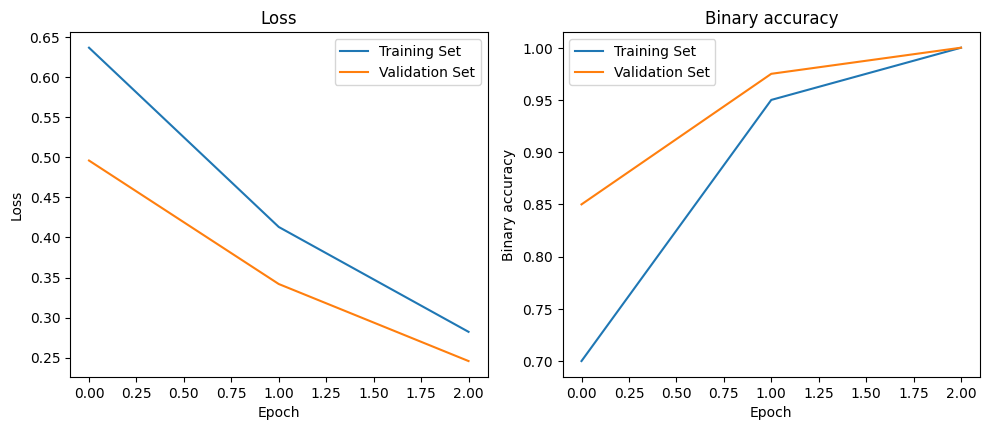

In [14]:
def plot_metrics(df_history):
    # first two columns are "epoch" and "phase", not metrics
    metrics = list(df_history.columns[2:])
    val_prefix = "val_"
    has_val = any(m.startswith(val_prefix) for m in metrics)
    if has_val:
        metrics = metrics[: len(metrics) // 2]

    num_cols = 2
    num_rows = len(metrics) // num_cols + 1

    plt.figure(figsize=(10, 4 * num_rows))
    for i, metric in enumerate(metrics):
        plt.subplot(num_rows, num_cols, i + 1)
        metric_name = metric.replace("_", " ").capitalize()
        plt.title(metric_name)
        plt.plot(df_history.epoch, df_history[metric], label="Training Set")
        if has_val:
            plt.plot(df_history.epoch, df_history[val_prefix + metric], label="Validation Set")
        plt.xlabel("Epoch")
        plt.ylabel(metric_name)
        plt.legend()
    plt.tight_layout()
    plt.show()


plot_metrics(df_history)

## Fine-Tuning

Now that the new final layer is trained, we unfreeze the *whole* model
and keep training with a very small learning rate. This lets the
pretrained features adjust slightly to our specific images, without
undoing everything they already learned.

In [15]:
base_model.trainable = True
# Recompile after changing `trainable` - Keras only picks up the change
# once the model is recompiled. We still pass training=False to the base
# model above, which keeps its BatchNorm layers using their pretrained
# statistics instead of the small batch statistics from our tiny dataset
# (using our batch statistics here would undo much of the pretraining).
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # much smaller learning rate than before
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[keras.metrics.BinaryAccuracy()],
)
# Notice the trainable parameter count jumped up now that everything is unfrozen
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 xception (Functional)       (None, 5, 5, 2048)        20861480  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 1)                 2049      
                                                                 
Total params: 20863529 (79.59 MB)
Trainable params: 20809001 (79.38 MB)
Non-trainable params: 54528 (213.00 KB)
_________________________________________________________________


In [16]:
history_fine_tuning = model.fit(
    preprocessed_train_ds, epochs=EPOCHS_FINE_TUNE, validation_data=preprocessed_val_ds
)
df_history = record_history(df_history, history_fine_tuning, "fine tuning")
plot_metrics(df_history)

Epoch 1/3


: 

In [ ]:
# Find the epoch with the lowest validation loss - a reasonable stopping
# point if you were to retrain with early stopping.
best_epoch_idx = df_history["val_loss"].idxmin()
df_history.loc[best_epoch_idx]

## Confusion Matrix

In [19]:
# model.predict returns one probability per image: how likely it is to be
# class 1. We turn that into hard 0/1 predictions and also keep the
# "confidence" (how far the probability was from 0.5) for later.
val_predict_proba_class1 = model.predict(preprocessed_val_ds).ravel()
val_predict_labels = (val_predict_proba_class1 > 0.5).astype(int)
val_predict_confidence = np.where(
    val_predict_labels == 1, val_predict_proba_class1, 1 - val_predict_proba_class1
)

val_labels = np.concatenate([y for _, y in preprocessed_val_ds], axis=0)
val_predict_labels[:10], val_labels[:10]


1/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 371ms/step


(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 0, 1, 0, 1, 1, 1, 0], dtype=int32))

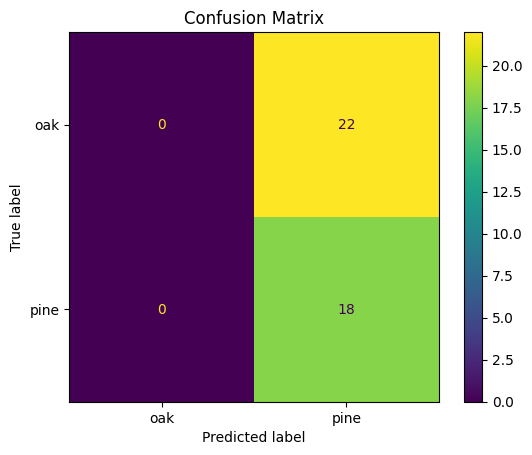

In [20]:
ConfusionMatrixDisplay.from_predictions(
    [class_names[i] for i in val_labels],
    [class_names[i] for i in val_predict_labels],
)
plt.title("Confusion Matrix")
plt.show()

In [21]:
val_images = np.concatenate([x for x, _ in val_ds], axis=0)

In [22]:
def show_images(indices, predict_labels, predict_confidence, ds_images, ds_labels, class_names, max_images=9):
    indices = indices[:max_images]
    num_cols = 3
    num_rows = len(indices) // num_cols + 1

    plt.figure(figsize=(num_cols * 3, num_rows * 3))
    for i, idx in enumerate(indices):
        ax = plt.subplot(num_rows, num_cols, i + 1)
        ax.imshow(ds_images[idx].astype("uint8"))
        true_label = class_names[ds_labels[idx]]
        pred_label = class_names[predict_labels[idx]]
        plt.title(f"{true_label}\n(predicted: {pred_label}, {predict_confidence[idx]:0.2f})")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## Correct Predictions

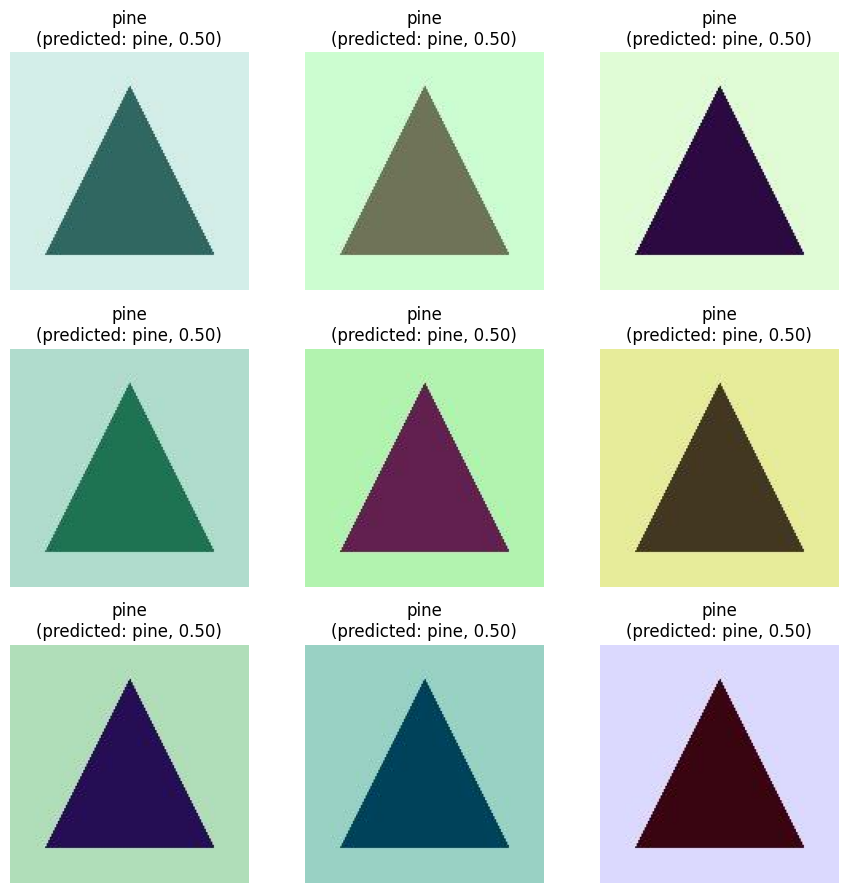

In [23]:
correct_idx = np.flatnonzero(val_predict_labels == val_labels)
# show the most confident correct predictions first
correct_idx_sorted = correct_idx[np.argsort(-val_predict_confidence[correct_idx])]
show_images(correct_idx_sorted, val_predict_labels, val_predict_confidence, val_images, val_labels, class_names)

## Incorrect Predictions

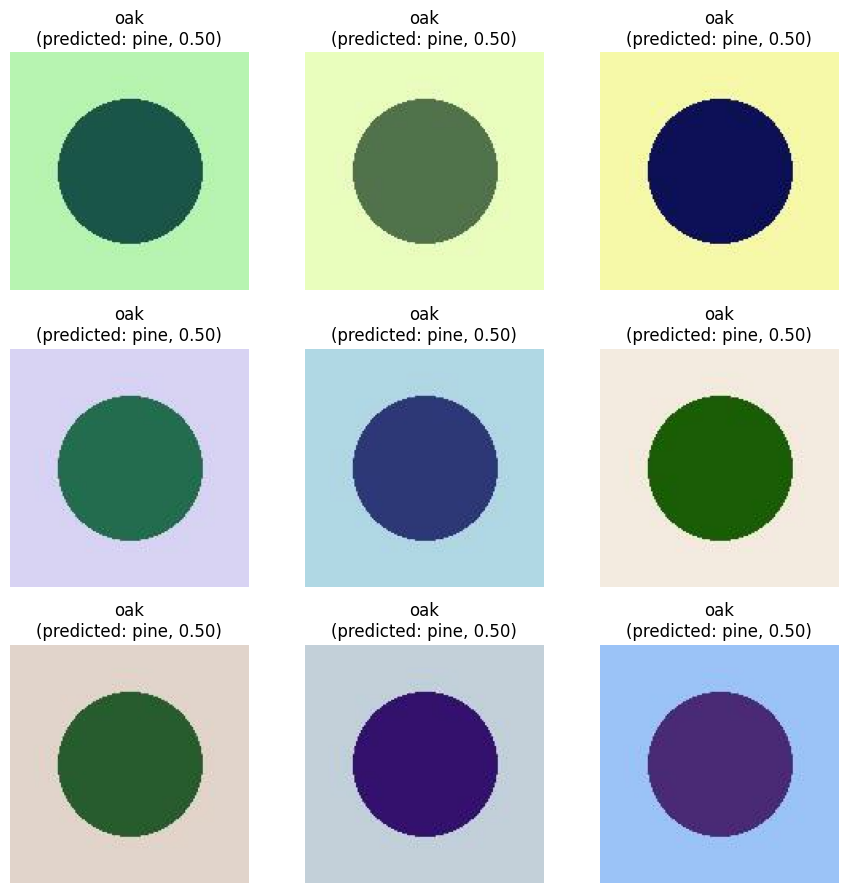

In [24]:
incorrect_idx = np.flatnonzero(val_predict_labels != val_labels)
incorrect_idx_sorted = incorrect_idx[np.argsort(-val_predict_confidence[incorrect_idx])]
show_images(incorrect_idx_sorted, val_predict_labels, val_predict_confidence, val_images, val_labels, class_names)

## Uncertain Predictions

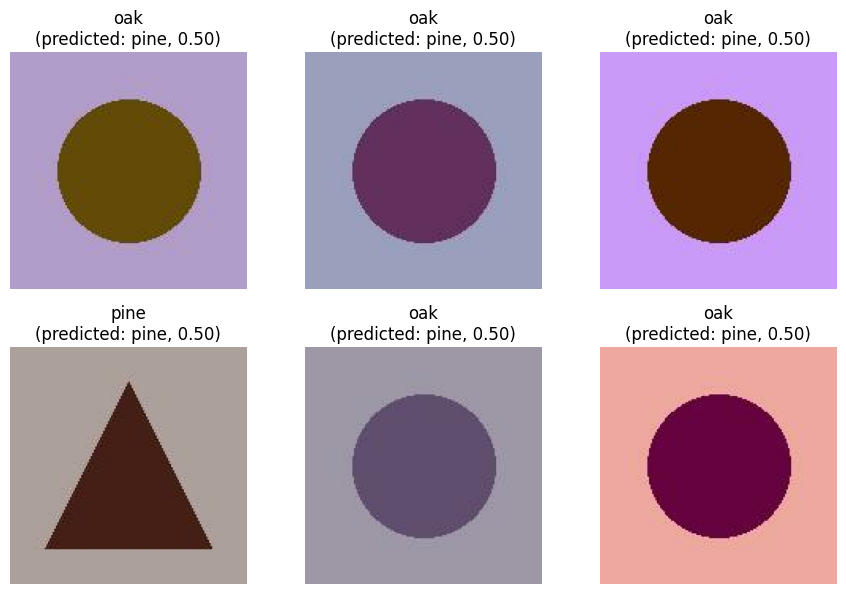

In [25]:
# predictions closest to 0.5 confidence = the model was least sure
uncertain_idx = np.argsort(val_predict_confidence)
show_images(uncertain_idx, val_predict_labels, val_predict_confidence, val_images, val_labels, class_names, max_images=6)

## Wrap-up

- If the messages above said *"Using real dataset"* and *"Loaded Xception
  with pretrained ImageNet weights"*, this ran the real transfer-learning
  pipeline.
- If they mentioned *"synthetic dataset"* and/or *"random initial
  weights"*, the notebook still ran end-to-end, but on generated
  stand-in data - useful for checking the code works, not for real
  accuracy numbers. Point `DATA_DIR` at your real image folder and run
  this somewhere with internet access to train on it for real.
- `EPOCHS_TRANSFER` and `EPOCHS_FINE_TUNE` are set low to keep this fast;
  increase them for a real training run.